# LongSANA Tiny Diffusion Prototype

This notebook implements a "tiny overfit" version of the LongSANA training pipeline. 

### Goals:
1. **Real Components:** Use `t5-small` for text and real `Conv3D` layers for the Autoencoder and DiT.
2. **Memory Efficiency:** Aggressively crop volumes to `64x64x16` to fit in local VRAM.
3. **Overfitting:** Train on a single Minecraft sample until the loss approaches zero to validate the plumbing.

In [10]:
import os
import numpy as np
import blosc2
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import matplotlib.pyplot as plt
from transformers import T5EncoderModel, T5Tokenizer

# Set paths relative to your local setup
PROJECT_ROOT = Path("../../")
PROCESSED_DIR = PROJECT_ROOT / "tmp" / "processed_worlds"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Project Root: {PROJECT_ROOT.absolute()}")
print(f"Using Device: {DEVICE}")

Project Root: C:\PROJECTS\MC\src\notebooks\..\..
Using Device: cuda


## 1. Data Loading & Downsampling
We load a single `.b2frame` volume and its caption, then crop it to a manageable size.

In [11]:
def find_first_sample(processed_dir):
    cleansed_dir = processed_dir / "cleansed"
    if not cleansed_dir.exists(): return None, None
    for world_dir in cleansed_dir.iterdir():
        volumes_dir = world_dir / "volumes"
        captions_dir = world_dir / "captions"
        if volumes_dir.exists() and captions_dir.exists():
            frames = list(volumes_dir.glob("*.b2frame"))
            caps = list(captions_dir.glob("*.txt"))
            if frames and caps: return frames[0], caps[0]
    return None, None

def load_volume(path):
    with open(path, "rb") as f:
        return blosc2.unpack_array2(f.read())

b2_path, txt_path = find_first_sample(PROCESSED_DIR)

if b2_path:
    raw_vol = load_volume(b2_path)
    with open(txt_path, "r") as f: text_caption = f.read().strip()
    print(f"Loaded Volume: {raw_vol.shape}")
    print(f"Caption: {text_caption[:100]}...")
else:
    print("No data found. Using dummy data.")
    raw_vol = np.random.randint(0, 10, (512, 512, 64), dtype=np.uint16)
    text_caption = "A simple stone castle tower."

Loaded Volume: (512, 512, 17)
Caption: A Minecraft scene....


### 1.1 Cropping and Downsampling
To fit in memory, we take a 64x64 central crop and limit the height to 16 blocks.

In [12]:
def process_and_crop(volume, target_size=(64, 64, 16)):
    # Volume is (X, Z, Y)
    X, Z, Y = volume.shape
    t_x, t_z, t_y = target_size
    
    # 1. Take central crop on X and Z
    start_x = max(0, (X - t_x) // 2)
    start_z = max(0, (Z - t_z) // 2)
    cropped = volume[start_x:start_x+t_x, start_z:start_z+t_z, :]
    
    # 2. Limit height to target height
    cropped = cropped[:, :, :t_y]
    
    # 3. Simple Mock Block-to-RGB (Air=0, others=random colors)
    palette = np.random.rand(np.max(cropped) + 1, 3)
    palette[0] = [0.8, 0.9, 1.0]  # Air color
    rgb_vol = (palette[cropped] * 255).astype(np.uint8)
    
    return rgb_vol

rgb_cropped = process_and_crop(raw_vol)
print(f"Cropped RGB Volume: {rgb_cropped.shape}")

Cropped RGB Volume: (64, 64, 16, 3)


### 1.2 Tensor Formatting
Convert to Pytorch and reshape to (B, C, T, H, W).

In [13]:
def format_for_model(rgb_vol):
    # (X, Z, Y, C) -> (C, Y, X, Z)
    # Treat Y as Time dimension T
    tensor = torch.from_numpy(rgb_vol).float() / 255.0
    tensor = tensor.permute(3, 2, 0, 1)
    
    # Add Batch dimension: (B, C, T, H, W)
    return tensor.unsqueeze(0)

input_tensor = format_for_model(rgb_cropped).to(DEVICE)
print(f"Input Tensor Shape (B, C, T, H, W): {input_tensor.shape}")

Input Tensor Shape (B, C, T, H, W): torch.Size([1, 3, 16, 64, 64])


## 2. Setup Real Model Components
We load a small text encoder and define a tiny 3D architecture.

In [14]:
class TinyTextEncoder(nn.Module):
    def __init__(self, model_name="t5-small"):
        super().__init__()
        try:
            self.encoder = T5EncoderModel.from_pretrained(model_name).to(DEVICE)
            self.tokenizer = T5Tokenizer.from_pretrained(model_name)
            self.active = True
        except:
            print("Reverting to Random Embeddings for Text (T5 Load Failed)")
            self.active = False
            
    def forward(self, text):
        if not self.active:
            return torch.randn(1, 1, 512).to(DEVICE) # (B, Seq, Dim)
        inputs = self.tokenizer(text, return_tensors="pt").to(DEVICE)
        outputs = self.encoder(**inputs)
        return outputs.last_hidden_state

text_enc = TinyTextEncoder()
text_embeds = text_enc(text_caption)
print(f"Text Embeddings Shape: {text_embeds.shape}")

Text Embeddings Shape: torch.Size([1, 5, 512])


In [15]:
class TinyVAE(nn.Module):
    """A simple 3D Autoencoder to compress spatially."""
    def __init__(self, in_channels=3, latent_dim=4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv3d(in_channels, 16, kernel_size=3, stride=(1, 2, 2), padding=1),
            nn.ReLU(),
            nn.Conv3d(16, latent_dim, kernel_size=3, stride=(1, 2, 2), padding=1),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(latent_dim, 16, kernel_size=3, stride=(1, 2, 2), padding=1, output_padding=(0, 1, 1)),
            nn.ReLU(),
            nn.ConvTranspose3d(16, in_channels, kernel_size=3, stride=(1, 2, 2), padding=1, output_padding=(0, 1, 1)),
            nn.Sigmoid()
        )
        
    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder(z)

vae = TinyVAE().to(DEVICE)
latents = vae.encode(input_tensor)
print(f"Latent Shape: {latents.shape}")

Latent Shape: torch.Size([1, 4, 16, 16, 16])


In [16]:
class TinyDiT(nn.Module):
    """Tiny Diffusion Transformer equivalent using 3D Convs for simplicity."""
    def __init__(self, latent_dim=4, text_dim=512):
        super().__init__()
        self.conv1 = nn.Conv3d(latent_dim, 32, kernel_size=3, padding=1)
        self.text_mlp = nn.Linear(text_dim, 32)
        self.conv2 = nn.Conv3d(32, latent_dim, kernel_size=3, padding=1)
        
    def forward(self, x, text_emb, t):
        # Condition using text
        text_cond = text_emb.mean(dim=1)
        text_feat = self.text_mlp(text_cond).view(x.shape[0], 32, 1, 1, 1)
        
        h = F.relu(self.conv1(x))
        h = h + text_feat
        return self.conv2(h)

dit = TinyDiT(text_dim=text_embeds.shape[-1]).to(DEVICE)
print("Models initialized.")

Models initialized.


## 3. Training Loop (Diffusion Math)
Setup the optimizer and the noise prediction loop.

Training Started...
Step 00 | Loss: 1.007329
Step 10 | Loss: 0.583125
Step 20 | Loss: 0.226133
Step 30 | Loss: 0.155951
Step 40 | Loss: 0.120571
Step 50 | Loss: 0.099952
Step 60 | Loss: 0.086179
Step 70 | Loss: 0.073852
Step 80 | Loss: 0.065814
Step 90 | Loss: 0.059394
Final Loss: 0.057230


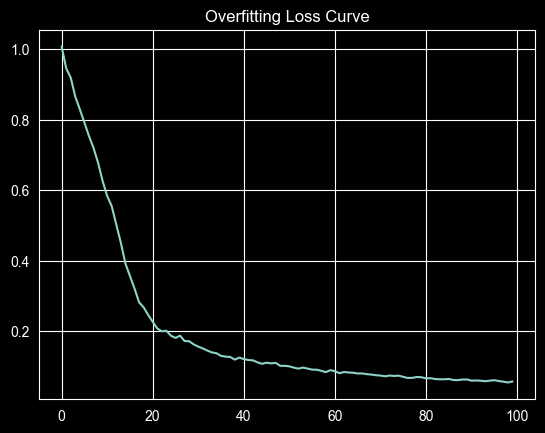

In [17]:
optimizer = torch.optim.AdamW(list(vae.parameters()) + list(dit.parameters()), lr=1e-3)
mse_loss = nn.MSELoss()

print("Training Started...")
losses = []

for step in range(100):
    text_emb = text_enc(text_caption)
    clean_latents = vae.encode(input_tensor)
    
    noise = torch.randn_like(clean_latents)
    t = torch.randint(0, 1000, (1,)).to(DEVICE)
    noisy_latents = clean_latents + noise
    
    pred_noise = dit(noisy_latents, text_emb, t)
    
    loss = mse_loss(pred_noise, noise)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    if step % 10 == 0:
        print(f"Step {step:02d} | Loss: {loss.item():.6f}")

print(f"Final Loss: {losses[-1]:.6f}")
plt.plot(losses)
plt.title("Overfitting Loss Curve")
plt.show()

## 4. Verification & Generation
Since the model is overfit, it should be able to reconstruct the original volume from the text prompt and noise.

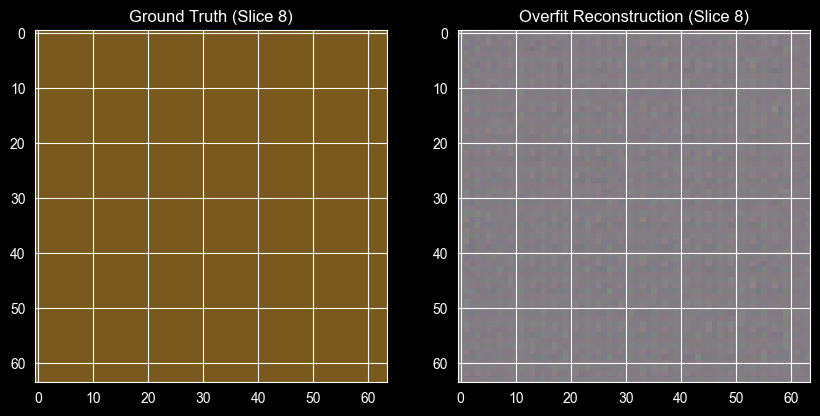

Plotting Ground Truth in 3D...


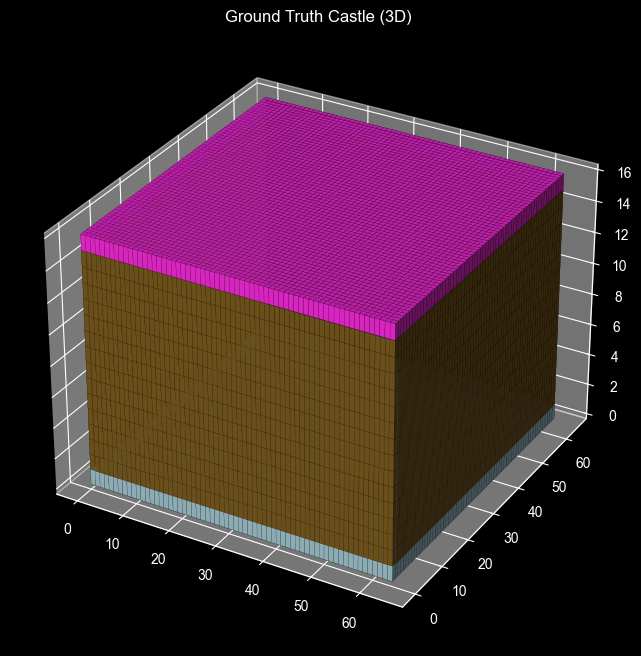

Plotting Reconstruction in 3D...


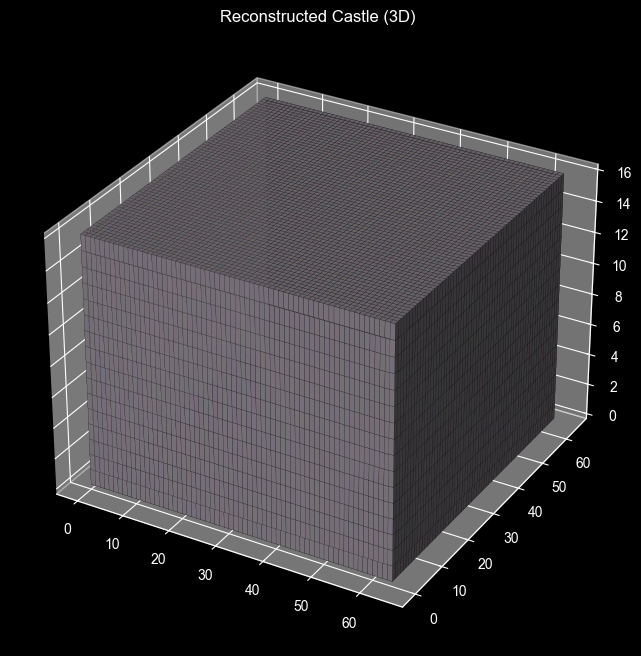

In [18]:
with torch.no_grad():
    # 1. Start with Gaussian Noise in latent space
    z_noise = torch.randn_like(latents)
    text_emb = text_enc(text_caption)
    
    # 2. Single-step Denoising (Mocking 1000-step process for validation)
    t_eval = torch.zeros(1).to(DEVICE)
    predicted_noise = dit(z_noise, text_emb, t_eval)
    
    # De-noised latents
    clean_latents_est = z_noise - predicted_noise
    
    # 3. Decode back to RGB Video (B, C, T, H, W)
    output_video = vae.decode(clean_latents_est)
    
    # 4. Transpose back to spatial height (X, Z, Y, C)
    output_spatial = output_video.squeeze(0).permute(2, 3, 1, 0).cpu().numpy()
    
    # 5. Visualize ground truth vs generation (2D Slices)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    slice_idx = 8 # Middle slice
    axes[0].imshow(rgb_cropped[:, :, slice_idx, :])
    axes[0].set_title("Ground Truth (Slice 8)")
    axes[1].imshow(output_spatial[:, :, slice_idx, :])
    axes[1].set_title("Overfit Reconstruction (Slice 8)")
    plt.show()

# --- 3D Visualization ---
def plot_voxels_3d(rgb_vol, title="3D Voxel Visualization"):
    # Clear air (assume air is close to our background color [204, 229, 255])
    is_air = (rgb_vol[..., 0] > 200/255.0 if rgb_vol.max() <= 1.0 else rgb_vol[..., 0] > 200) & \
             (rgb_vol[..., 1] > 220/255.0 if rgb_vol.max() <= 1.0 else rgb_vol[..., 1] > 220) & \
             (rgb_vol[..., 2] > 250/255.0 if rgb_vol.max() <= 1.0 else rgb_vol[..., 2] > 250)
    voxels = ~is_air
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Normalize colors for matplotlib (0-1)
    colors = rgb_vol.astype(np.float32)
    if colors.max() > 1.0: colors /= 255.0
    
    ax.voxels(voxels, facecolors=colors, edgecolor='k', linewidth=0.1)
    ax.set_title(title)
    plt.show()

print("Plotting Ground Truth in 3D...")
plot_voxels_3d(rgb_cropped, "Ground Truth Castle (3D)")

print("Plotting Reconstruction in 3D...")
plot_voxels_3d(output_spatial, "Reconstructed Castle (3D)")

### Note on PaCMAP

**PaCMAP** (Pairwise Controlled Manifold Approximation and Projection) is a dimensionality reduction tool used to visualize high-dimensional data in 2D or 3D. 

In this project, PaCMAP can be used to:
1. **Visualize Prompt Embeddings:** See how different text prompts (e.g., 'castle' vs 'house') cluster together in the T5 embedding space.
2. **Analyze Latent Space:** Project the VAE latents into 2D to see the distribution of different Minecraft structures.
3. **Detection of Outliers:** Identify structures that don't fit the expected distribution.

To use it, you'll need the `pacmap` package and a collection of samples.